In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import os

In [2]:
os.listdir('train/')

['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

In [3]:
temp_image = mpimg.imread('test/disgusted/im1.png')

In [4]:
temp_image.shape

(48, 48)

In [5]:
temp_image = mpimg.imread('train/angry/im1.png')

In [6]:
temp_image.shape

(48, 48)

In [7]:
temp_image = mpimg.imread('train/disgusted/im1.png')

In [8]:
temp_image.shape

(48, 48)

In [9]:
temp_image = mpimg.imread('train/fearful/im1.png')

In [10]:
temp_image.shape

(48, 48)

In [11]:
temp_image = mpimg.imread('train/happy/im0.png')

In [12]:
temp_image.shape

(48, 48)

In [13]:
temp_image = mpimg.imread('train/happy/im1.png')

In [14]:
temp_image.shape

(48, 48)

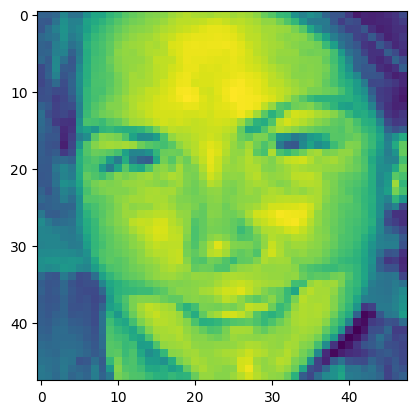

In [15]:
plt.imshow(temp_image)

In [16]:
data = {
    'angry':0,
    'disgusted':1,
    'fearful':2,
    'happy':3,
    'neutral':4,
    'sad':5,
    'surprised':6
}

In [17]:
X_train = []
y_train = []
for i in os.listdir('train/'):
    for j in os.listdir(f'train/{i}/'):
        try:
            
            image = cv2.imread(f'train/{i}/{j}')
            image = cv2.resize(image, (48, 48))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            image = image.reshape(48, 48, 1)
            X_train.append(image)
            y_train.append(data[i])

        except:
            continue

X_train = np.array(X_train)
y_train = np.array(y_train)

In [18]:
data2 = {
    'angry':0,
    'disgusted':1,
    'fearful':2,
    'happy':3,
    'neutral':4,
    'sad':5,
    'surprised':6
}

In [19]:
X_test = []
y_test = []

for i in os.listdir('test/'):
    for j in os.listdir(f'test/{i}/'):
        try:
            image = cv2.imread(f'test/{i}/{j}')
            image = cv2.resize(image, (48, 48))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            image = image.reshape(48, 48, 1)
    
            X_test.append(image)
            y_test.append(data2[i])
        except:
            continue

X_test = np.array(X_test)
y_test = np.array(y_test)

In [20]:
X_train

array([[[[ 70],
         [ 80],
         [ 82],
         ...,
         [ 52],
         [ 43],
         [ 41]],

        [[ 65],
         [ 61],
         [ 58],
         ...,
         [ 56],
         [ 52],
         [ 44]],

        [[ 50],
         [ 43],
         [ 54],
         ...,
         [ 49],
         [ 56],
         [ 47]],

        ...,

        [[ 91],
         [ 65],
         [ 42],
         ...,
         [ 72],
         [ 56],
         [ 43]],

        [[ 77],
         [ 82],
         [ 79],
         ...,
         [105],
         [ 70],
         [ 46]],

        [[ 77],
         [ 72],
         [ 84],
         ...,
         [106],
         [109],
         [ 82]]],


       [[[151],
         [150],
         [147],
         ...,
         [129],
         [140],
         [120]],

        [[151],
         [149],
         [149],
         ...,
         [122],
         [141],
         [137]],

        [[151],
         [151],
         [156],
         ...,
         [109],
         [

In [21]:
y_train

array([0, 0, 0, ..., 6, 6, 6], shape=(28709,))

In [22]:
X_test

array([[[[254],
         [254],
         [254],
         ...,
         [ 16],
         [  0],
         [161]],

        [[254],
         [254],
         [254],
         ...,
         [ 17],
         [  0],
         [122]],

        [[254],
         [254],
         [254],
         ...,
         [ 26],
         [  0],
         [114]],

        ...,

        [[ 66],
         [ 86],
         [ 99],
         ...,
         [255],
         [252],
         [254]],

        [[ 84],
         [ 92],
         [ 92],
         ...,
         [236],
         [255],
         [255]],

        [[ 93],
         [ 90],
         [ 85],
         ...,
         [ 42],
         [129],
         [180]]],


       [[[176],
         [177],
         [170],
         ...,
         [ 94],
         [ 87],
         [108]],

        [[181],
         [180],
         [180],
         ...,
         [ 98],
         [ 89],
         [ 97]],

        [[178],
         [182],
         [187],
         ...,
         [ 95],
         [

In [23]:
y_test

array([0, 0, 0, ..., 6, 6, 6], shape=(7178,))

In [24]:
from sklearn.utils import shuffle
X_train,y_train = shuffle(X_train,y_train,random_state=42)

In [25]:
X_train.shape

(28709, 48, 48, 1)

In [37]:
y_train.shape

(28709, 7, 7)

In [27]:
from keras.utils import to_categorical

In [34]:
y_train = to_categorical(y_train,num_classes=7)
y_test = to_categorical(y_test,num_classes=7)

In [35]:
y_train.shape

(28709, 7, 7)

In [39]:
y_test.shape

(7178, 7)

In [57]:
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D, Flatten, Dense

In [58]:
model = Sequential()
model.add(Conv2D(filters = 32,kernel_size=(3,3), activation='relu',padding='same', input_shape = (48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=7, activation='softmax'))


In [59]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [60]:
model.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=20,batch_size = 32)

Epoch 1/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 74s 36ms/step - accuracy: 0.3092 - loss: 0.4354 - val_accuracy: 0.3845 - val_loss: 0.3594
Epoch 2/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 36s 30ms/step - accuracy: 0.4113 - loss: 0.3451 - val_accuracy: 0.4172 - val_loss: 0.3416
Epoch 3/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 45s 35ms/step - accuracy: 0.4394 - loss: 0.3301 - val_accuracy: 0.4274 - val_loss: 0.3347
Epoch 4/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.4582 - loss: 0.3191 - val_accuracy: 0.4429 - val_loss: 0.3290
Epoch 5/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.4819 - loss: 0.3084 - val_accuracy: 0.4440 - val_loss: 0.3277
Epoch 6/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.5046 - loss: 0.2972 - val_accuracy: 0.4493 - val_loss: 0.3281
Epoch 7/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.5291 - loss: 0.2847 - val_accuracy: 0.4471 - val_loss: 0.3271
Epoch 8/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.5522 - loss: 0.2728 - 

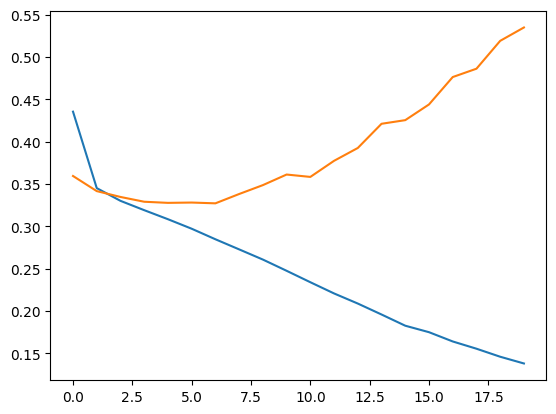

In [68]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

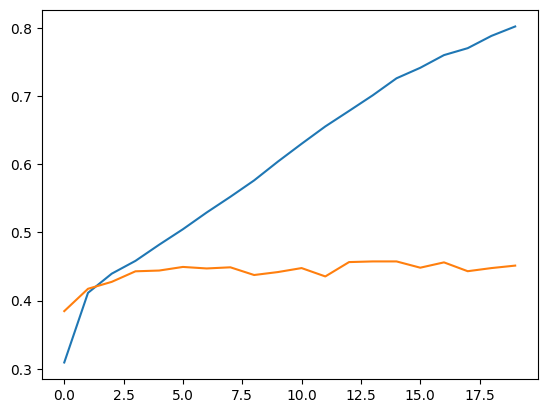

In [69]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

In [66]:
print(X_test.shape)
print(y_test.shape)

(7178, 48, 48, 1)
(7178, 7)


In [67]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4512 - loss: 0.5348
Test Accuracy: 45.12%


In [38]:
import numpy as np
from keras.utils import to_categorical

# вернуть к обычным классам
y_test = np.argmax(y_test, axis=-1)

# если форма всё ещё не (7178,)
while len(y_test.shape) > 1:
    y_test = np.argmax(y_test, axis=-1)

# теперь заново one-hot ОДИН раз
y_test = to_categorical(y_test, 7)

print(y_test.shape)

(7178, 7)


In [45]:
import numpy as np
from keras.utils import to_categorical

# вернуть к обычным классам
y_train = np.argmax(y_train, axis=-1)

# если форма всё ещё не (7178,)
while len(y_train.shape) > 1:
    y_train = np.argmax(y_train, axis=-1)

# теперь заново one-hot ОДИН раз
y_train = to_categorical(y_train, 7)

print(y_train.shape)

(28709, 7)
